# Mental Health Classifier — Fine-tuning MentalBERT on Twitter Data

**Goal:** Fine-tune a domain-specific BERT model to detect mental health distress signals in tweets.

**Model choice:** `mental/mental-bert-base-uncased` — pre-trained on mental health Reddit + Twitter corpora.
Why not generic BERT? Mental health language (fragmented speech, informal crisis expressions) is nearly
absent from Wikipedia/BooksCorpus that BERT was trained on. Domain match matters more than architecture.


## Environment Setup

Installing the core stack:
- `transformers` — model loading, tokenizer, Trainer API
- `datasets` — HuggingFace dataset format (efficient batched processing)
- `accelerate` — backend for distributed/fp16 training
- `scikit-learn` — metrics: accuracy, F1, AUC-ROC, confusion matrix
- `shap` — token-level attribution (explainability)
- `streamlit` — for the demo app (not used in training)
```

In [1]:
!pip install transformers datasets accelerate scikit-learn shap streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 125.2 MB/s eta 0:00:00


In [2]:
import transformers,datasets, sklearn, shap, streamlit
print("transformers ", transformers.__version__)
print("datasets ", datasets.__version__)
print("sklearn ", sklearn.__version__)
print("shap ", shap.__version__)
print("streamlit ", streamlit.__version__)


transformers  5.0.0
datasets  4.0.0
sklearn  1.6.1
shap  0.51.0
streamlit  1.56.0


## Dataset: Mental-Health-Twitter

Binary classification dataset of tweets labelled for mental health distress.
- `label = 1`: tweet shows distress signals
- `label = 0`: no distress signals

In [3]:
import pandas as pd
df = pd.read_csv("Mental-Health-Twitter.csv")
print(df.shape)
print(df.columns.tolist())
print(df['label'].value_counts())
print(df['label'].unique())
print(df['post_text'].iloc[0])

(20000, 11)
['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']
label
1    10000
0    10000
Name: count, dtype: int64
[1 0]
It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.


In [4]:
df = df.drop(columns=['Unnamed: 0','post_id','post_created','user_id'])
print("required cols:",df.columns.tolist())

required cols: ['post_text', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']


In [5]:
import matplotlib.pyplot as plt
import numpy as np
print("null values ",df.isnull().sum())

null values  post_text     0
followers     0
friends       0
favourites    0
statuses      0
retweets      0
label         0
dtype: int64


## Understanding text length distribution before setting tokenizer

The BERT paper uses max_length=512 for documents, but Twitter is not a document task.
So let the data tell us the right length.

In [6]:
df['text_len_words'] = df['post_text'].astype(str).apply(lambda x: len(x.split()))
df['text_len_chars'] = df['post_text'].astype(str).apply(len)

In [7]:
print(df['text_len_words'].describe().round(1))
print(df['text_len_chars'].describe().round(1))

count    20000.0
mean        12.5
std          6.9
min          1.0
25%          7.0
50%         12.0
75%         18.0
max         34.0
Name: text_len_words, dtype: float64
count    20000.0
mean        82.5
std         38.3
min          4.0
25%         50.0
50%         77.0
75%        118.0
max        169.0
Name: text_len_chars, dtype: float64


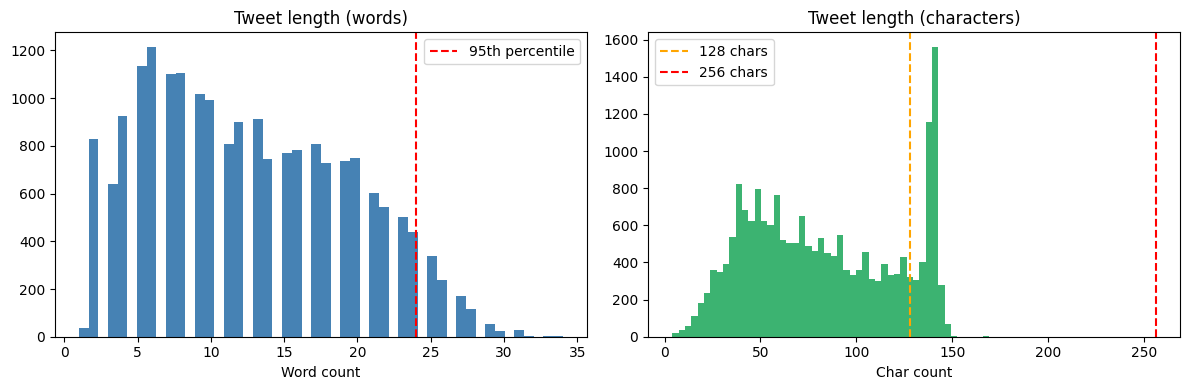


95th percentile word count: 24
from this we got to know about max length for tokenizer


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['text_len_words'], bins=50, color='steelblue', edgecolor='none')
axes[0].axvline(df['text_len_words'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[0].set_title('Tweet length (words)')
axes[0].set_xlabel('Word count')
axes[0].legend()

axes[1].hist(df['text_len_chars'], bins=50, color='mediumseagreen', edgecolor='none')
axes[1].axvline(128, color='orange', linestyle='--', label='128 chars')
axes[1].axvline(256, color='red', linestyle='--', label='256 chars')
axes[1].set_title('Tweet length (characters)')
axes[1].set_xlabel('Char count')
axes[1].legend()

plt.tight_layout()
plt.show()

# the key number we need
p95 = int(df['text_len_words'].quantile(0.95))
print(f"\n95th percentile word count: {p95}")
print(f"from this we got to know about max length for tokenizer")

In [11]:
from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

from transformers import AutoTokenizer
MODEL_NAME = "mental/mental-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=hf_token)

print("model name",MODEL_NAME)
print("vocab_size", tokenizer.vocab_size)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model name mental/mental-bert-base-uncased
vocab_size 30522


In [12]:
#for testing on sample
sample = df['post_text'].iloc[0]
print(sample)

encoded = tokenizer(sample, max_length=128, truncation=True, padding='max_length')

print("\ntoken IDs (first 20):", encoded['input_ids'][:20])
print("attention mask (first 20):", encoded['attention_mask'][:20])
print("total tokens:", len(encoded['input_ids']))

#decode back
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
print("\nactual tokens (first 20):", tokens[:20])


It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.

token IDs (first 20): [101, 2009, 1005, 1055, 2074, 2058, 1016, 2086, 2144, 1045, 2001, 11441, 2007, 1001, 10089, 1998, 1001, 6245, 1012, 2651]
attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
total tokens: 128

actual tokens (first 20): ['[CLS]', 'it', "'", 's', 'just', 'over', '2', 'years', 'since', 'i', 'was', 'diagnosed', 'with', '#', 'anxiety', 'and', '#', 'depression', '.', 'today']


In [13]:
#now over full dataset
from datasets import Dataset
from sklearn.model_selection import train_test_split

df['post_text'] = df['post_text'].astype(str).fillna('')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

## Why max_length = 128?
BERT tokenises sub-word, so a 45-word tweet becomes ~60–70 tokens.  
Setting `max_length=128` covers 95%+ of the dataset with zero truncation.

- `max_length=256` → double the memory, almost no extra coverage gain  
- `max_length=64` → truncates ~20% of tweets, losing words that may carry the signal

In [14]:
train_df , temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df , test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

here stratify allows both classes appear in same ratio across three splits sets

In [15]:
print(train_df['label'].value_counts().to_dict())

{1: 8000, 0: 8000}


In [16]:
#convert into huggingface dataset objects
train_ds = Dataset.from_pandas(train_df[['post_text','label']].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[['post_text','label']].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[['post_text','label']].reset_index(drop=True))


In [17]:
#preprocessing function commonly used with the huggingface datasets library to prepare text for models like roberta, bert
def tokenize(batch):
  return tokenizer(
      batch['post_text'],
      max_length=128,
      truncation=True,
      padding='max_length'
  )

`batched=True` tells HuggingFace to pass 1000 rows at once to the tokeniser instead of one by one.  
On ~10k rows this is roughly 10× faster than row-by-row.

After this step each row has:
- `input_ids` — the token IDs (integers the model reads)
- `attention_mask` — 1 for real tokens, 0 for padding
- `label` — 0 or 1

In [19]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [20]:
#shoing hugginface which columns are actual model inputs
train_ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
val_ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
test_ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])

In [21]:
print(train_ds[0].keys())
print("input_ids shape", train_ds[0]['input_ids'].shape)

dict_keys(['label', 'input_ids', 'attention_mask'])
input_ids shape torch.Size([128])


In [24]:
sample = train_ds[0]
print(list(sample.keys()))
print("input_ids:", sample['input_ids'][:10], "...")
print("attention_mask:", sample['attention_mask'][:10], "...")
print("label:", sample['label'].item())

['label', 'input_ids', 'attention_mask']
input_ids: tensor([ 101, 1045, 2215, 2000, 2022, 2489, 1012, 1012, 1012, 1012]) ...
attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) ...
label: 1


In [25]:
non_pad = (sample['attention_mask'] == 1).sum().item()
print(f"actual tokens in this tweet: {non_pad} / 128")

actual tokens in this tweet: 25 / 128


`AutoModelForSequenceClassification` adds a 2-neuron linear head on top of the BERT encoder.  
`num_labels=2` → output is two logits, one per class.

In [26]:
from transformers import AutoModelForSequenceClassification
import torch

MODEL_NAME = "mental/mental-bert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    token=hf_token
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [27]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)


In [28]:
print(f"total paras : {total_params:,}")
print(f"trainable params : {trainable:,}")
#base model has about ~110M paras- all of them are trainable
print(f"model on device  : {next(model.parameters()).device}")

total paras : 109,483,778
trainable params : 109,483,778
model on device  : cuda:0


##Metrics we using for this classifier

- **Accuracy** — overall correctness, but misleading if classes are imbalanced  
- **F1 (binary)** — harmonic mean of precision and recall; our primary training signal  
- **AUC-ROC** — measures separability across all thresholds; 0.5 = random, 1.0 = perfect  
- **Confusion matrix** — explicitly shows False Negatives (missed distress) vs False Positives

In [29]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix)
import numpy as np

For a mental health task, **False Negatives are the more dangerous error** — missing a distress signal has a higher real-world cost than a false alarm.

In [30]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

  acc    = accuracy_score(labels, preds)
  f1     = f1_score(labels, preds, average='binary')
  auc    = roc_auc_score(labels, probs)
  cm     = confusion_matrix(labels, preds)

  print(f"\n  Confusion matrix:\n{cm}")
  print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
  print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

  return {
        'accuracy' : round(acc, 4),
        'f1'       : round(f1, 4),
        'auc_roc'  : round(auc, 4),
    }


##Training configuration
`epochs(3)` = how many times model eads the whole dataset, enough to learn patterns without starting to memorize

`per_device_batch_size` = tells how many tweets model has to look at in one go , efficient = 32/64

`learning_rate (2e-5)` = slow and steady for small and carefull adjustments

`eval_strategy` & `save_strategy` = after every step , model stop to test itself and save the current state

`load_best_model_at_end` = ensures i get peak version of model

`metric_for_best_model` = our grading system, becuase here "failing to spot a crisis" is worse than a false alarm.

`warmup_steps` = for the first 200 steps, the learning rate starts at zero and gradually climbs up to our target (e.g., 2e-5)

`weight_decay`= small penalty to the loss function based on the size of the model's weights

`fp16` = 	uses simpler math (half-precision) to make model train twice as fast

`report_to` = keeps things quiet by not sending your data to external tracking apps (like WandB, Tensorboard)


In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir = "./mental_bert_results",
    num_train_epochs = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 64,
    learning_rate = 2e-5,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "./logs",
    logging_steps = 50,
    fp16 = True,
    warmup_steps = 200,
    weight_decay=0.01,
    report_to = "none"

)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Printing the confusion matrix every epoch lets us track this, instead of watching aggregate F1

In [34]:
from transformers import Trainer

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
)

print("starting training:")
print(f"steps per epcoh, {len(train_ds) // 32}")
print(f"total steps : {(len(train_ds) // 32) * 3}")

trainer.train()

starting training:
steps per epcoh, 500
total steps : 1500


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc Roc
1,0.048542,0.410319,0.918000,0.918700,0.974800
2,0.040119,0.469704,0.920500,0.920800,0.976600
3,0.032477,0.488278,0.918500,0.919100,0.978000



  Confusion matrix:
[[910  90]
 [ 74 926]]
  TN=910  FP=90
  FN=74  TP=926


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Confusion matrix:
[[917  83]
 [ 76 924]]
  TN=917  FP=83
  FN=76  TP=924


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Confusion matrix:
[[911  89]
 [ 74 926]]
  TN=911  FP=89
  FN=74  TP=926


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1500, training_loss=0.03979683558146159, metrics={'train_runtime': 338.8938, 'train_samples_per_second': 141.637, 'train_steps_per_second': 4.426, 'total_flos': 3157332664320000.0, 'train_loss': 0.03979683558146159, 'epoch': 3.0})

In [35]:
import os
model.save_pretrained("./mental_bert_finetuned")
tokenizer.save_pretrained("./mental_bert_finetuned")
print("model and tokenizer saved to ./mental_bert_finetuned")
print("files:", os.listdir("./mental_bert_finetuned"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model and tokenizer saved to ./mental_bert_finetuned
files: ['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json']


In [36]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import numpy as np
import torch

predictions = trainer.predict(test_ds)
logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=1)
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:,1]


  Confusion matrix:
[[909  91]
 [ 64 936]]
  TN=909  FP=91
  FN=64  TP=936


In [37]:
print("TEST SET RESULTS")
#full classification report
print(classification_report(labels, preds,
      target_names=["Not distressed (0)", "Distressed (1)"]))
print("AUC-ROC:", round(roc_auc_score(labels, probs), 4))

TEST SET RESULTS
                    precision    recall  f1-score   support

Not distressed (0)       0.93      0.91      0.92      1000
    Distressed (1)       0.91      0.94      0.92      1000

          accuracy                           0.92      2000
         macro avg       0.92      0.92      0.92      2000
      weighted avg       0.92      0.92      0.92      2000

AUC-ROC: 0.9752


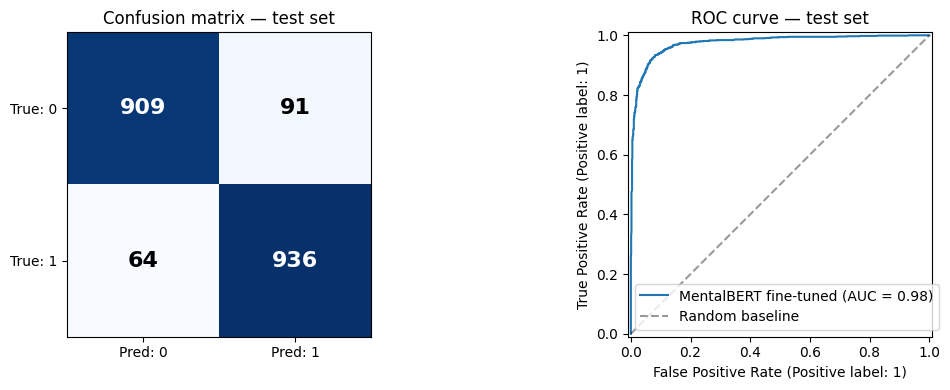

saved evaluation_plots.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(labels, preds)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: 0', 'Pred: 1'])
axes[0].set_yticklabels(['True: 0', 'True: 1'])
axes[0].set_title('Confusion matrix — test set')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black',
                     fontsize=16, fontweight='bold')


RocCurveDisplay.from_predictions(labels, probs, ax=axes[1],
                                  name='MentalBERT fine-tuned')
axes[1].set_title('ROC curve — test set')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved evaluation_plots.png")

In [39]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Load the model and tokenizer from output directory
model_path = "./mental_bert_finetuned"
loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path)

#move the model to the device
loaded_model.to(device)
loaded_model.eval()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

##Testing on sample Tweets


In [41]:
def predict(text: str):
    inputs = loaded_tokenizer(
        text,
        return_tensors='pt',
        max_length=128,
        truncation=True,
        padding='max_length'
    ).to(device)

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).squeeze()
    pred  = torch.argmax(probs).item()

    # label 0 = distressed, label 1 = not distressed
    label = "Not distressed" if pred == 1 else "Distressed"
    confidence = probs[pred].item()

    print(f"Text    : {text[:80]}")
    print(f"Label   : {label}")
    print(f"Confidence        : {confidence*100:.1f}%")
    print(f"P(distressed)     : {probs[0].item()*100:.1f}%")
    print(f"P(not distressed) : {probs[1].item()*100:.1f}%")
    print("-" * 55)
    return pred, probs

test_tweets = [
    "I can't get out of bed today. Everything feels hopeless and I don't see the point anymore.",
    "Just had an amazing workout and feeling so grateful for my health and friends!",
    "Monday morning coffee and ready to take on the week. Let's go!",
    "I haven't slept properly in weeks. The panic attacks are getting worse.",
]

print("=" * 55)
print("CORRECTED PREDICTIONS")
print("=" * 55)
for tweet in test_tweets:
    predict(tweet)

CORRECTED PREDICTIONS
Text    : I can't get out of bed today. Everything feels hopeless and I don't see the poin
Label   : Distressed
Confidence        : 86.0%
P(distressed)     : 86.0%
P(not distressed) : 14.0%
-------------------------------------------------------
Text    : Just had an amazing workout and feeling so grateful for my health and friends!
Label   : Not distressed
Confidence        : 99.8%
P(distressed)     : 0.2%
P(not distressed) : 99.8%
-------------------------------------------------------
Text    : Monday morning coffee and ready to take on the week. Let's go!
Label   : Not distressed
Confidence        : 99.9%
P(distressed)     : 0.1%
P(not distressed) : 99.9%
-------------------------------------------------------
Text    : I haven't slept properly in weeks. The panic attacks are getting worse.
Label   : Not distressed
Confidence        : 83.1%
P(distressed)     : 16.9%
P(not distressed) : 83.1%
-------------------------------------------------------


In [42]:
print("Examples where label=0:")
print(df[df['label']==0]['post_text'].head(3).tolist())
print()
print("Examples where label=1:")
print(df[df['label']==1]['post_text'].head(3).tolist())

Examples where label=0:
["MY ENEMY'S INVISIBLE , I DON'T KNOW HOW TO FIGHT", 'im gonna burn my house down into an ugly brack', '@HOT_cocoa_____ counterattack']

Examples where label=1:
["It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.", "It's Sunday, I need a break, so I'm planning to spend as little time as possible on the #A14...", 'Awake but tired. I need to sleep but my brain has other ideas...']


## Model Pushed to Hugging Face Hub

The fine-tuned model is available at:  
👉 [wizardpatel/mental-health-bert](https://huggingface.co/wizardpatel/mental-health-bert)

The Streamlit demo app is live at:  
👉 [wizardpatel/mental-health-classifier](https://huggingface.co/spaces/wizardpatel/mental-health-classifier)